In [ ]:
%pip install langchain_groq

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from langchain_groq import ChatGroq

import requests
import random

In [4]:
from google.colab import userdata
api_key = userdata.get('GROQ_API_KEY1')
api_key_2 = userdata.get('GROQ_API_KEY2')

In [5]:
parent_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=api_key,
    verbose=True,
    # other params...
)

subgraph_llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=api_key_2,
    verbose=True,
    # other params...
)

In [6]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [7]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()

    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [8]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [9]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [11]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
### we have added a subgraph in a node
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

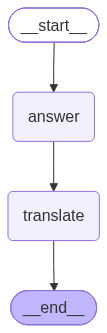

In [12]:
graph = parent_builder.compile()

graph

In [13]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '**Quantum physics** (also called quantum mechanics or quantum theory) is the branch of physics that describes how matter and energy behave at the smallest scales—typically at the level of atoms, electrons, photons, and other sub‑atomic particles.  \n\n### Why a new theory was needed\nClassical physics (Newtonian mechanics, electromagnetism, thermodynamics) works extremely well for everyday objects, but experiments in the early\u202f20th\u202fcentury showed that it could not explain phenomena such as:\n\n* **Black‑body radiation** (the “ultraviolet catastrophe”)\n* **The photoelectric effect** (light ejecting electrons from metal)\n* **Atomic spectra** (discrete lines of light emitted by atoms)\n* **Stability of atoms** (why electrons don’t spiral into the nucleus)\n\nThese puzzles forced physicists to develop a new framework—quantum physics.\n\n### Core Principles\n\n| Principle | What it says | Everyday analogy (if any) |\n|-----